In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

import pymc as pm
import arviz as az

from scipy.stats import wilcoxon

from joblib import dump, load

from xai_aux import CFCalculations

pd.set_option("display.max_columns", 99)

In [120]:
# Significance stars helper
def p_to_stars(p):
    if p is None or np.isnan(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

In [121]:
def get_distance(A,B, continuous_columns, categorical_columns, l_norm=2, n_features=1):
    
    combined = np.vstack((A, B))
    
    stds = np.std(combined[:, categorical_columns], axis=0)
    epsilon = 1e-8
    adjusted_stds = np.where(stds == 0, epsilon, stds) 

    weights_categorical = 1.48 / adjusted_stds
    mads = np.median(np.abs(combined[:, continuous_columns] - 
                            np.median(combined[:, continuous_columns], axis=0)), axis=0)
    adjusted_mads = np.where(mads == 0, epsilon, mads) 
    weights_continuous = 1 / adjusted_mads

    # Combine weights
    weights = np.zeros(combined.shape[1])
    weights[categorical_columns] = weights_categorical
    weights[continuous_columns] = weights_continuous

    # Compute weighted L2 distances for same-index pairs
    differences = A - B  # Element-wise differences
    weighted_differences = differences * weights  # Apply weights element-wise
    l_distances = np.linalg.norm(weighted_differences, axis=1, ord=l_norm) #/n_features
    baseline_norm = np.linalg.norm(B * weights, axis=1, ord=l_order)
    relative_distances = l_distances / baseline_norm
    return relative_distances

In [122]:
l_order = 1
completeness_limit = 0.88
cm = ['TP','FP','FN','TN']

colours = {('lr', 'skl'): 'deepskyblue', 
           ('lr', 'blr_marg'): 'blue', 
           ('lr', 'blr_mean'): 'lightblue',
           ('lr', 'nice'): 'magenta',
           ('lr', 'dice'): 'hotpink', 
           ('lr', 'RL'): 'lavender',
           ('rf', 'nice'): 'darkorange',
           ('rf', 'dice'): 'orange',
           ('rf', 'RL'): 'palegoldenrod',
           ('tf', 'nice'): 'darkgreen', 
           ('tf', 'dice'): 'lightgreen'
           }

In [123]:
def load_dataset(dataset_name, variant="standard",n_datasets=11):
    """
    Load only the requested dataset variant.
    
    Parameters:
        dataset_name (str): Name of the dataset (e.g., "mock_data_3", "gsc", etc.).
        variant (str): One of ["standard", "noniid_test", "ommited_var_test"].
    
    Returns:
        dict: Loaded dataset components.
    """
    base_path = f"/Users/leo/xai-cfs/data/{dataset_name}"
    print(base_path)
    
    # Validate variant
    if variant not in ["standard", "noniid_test", "ommited_var_test"]:
        raise ValueError(f"Unknown variant: {variant}")

    # Special handling for mock datasets
    if dataset_name.startswith("mock_data"):
        mock_num = dataset_name[-1]
        
        # Only mock_data_3 supports extra variants
        if variant in ["noniid_test", "ommited_var_test"] and mock_num != "3":
            raise ValueError(f"{variant} is only available for mock_data_3")

    # Define paths based on the variant
    if variant == "standard":
        dataset_path = f"{base_path}_cf_results_dict.pkl"
        model_results_path = f"{base_path}_model_results.pkl"
        cfs_good_indices_path = f"{base_path}_cfs_good_indices.pkl"
        cf_calc_paths = [f"{base_path}_{i}.pkl" for i in range(n_datasets)]
    else:
        dataset_path = f"{base_path}_{variant}_cf_results_dict.pkl"
        model_results_path = f"{base_path}_{variant}_model_results.pkl"
        cfs_good_indices_path = f"{base_path}_{variant}_cfs_good_indices.pkl"
        cf_calc_paths = [f"{base_path}_{variant}{i}.pkl" for i in range(n_datasets)]

    # Load only the requested dataset
    return {
        "cf_results_dict": load(dataset_path),
        "cf_calc": [load(path) for path in cf_calc_paths],
        "model_results_dict": load(model_results_path),
        "cfs_good_indices": load(cfs_good_indices_path),
    }

In [124]:
# Choose dataset dynamically
dataset = "gsc" # options: "adult_income" "german_credit" "gsc" "mock_data3"
variant = "standard"  # "noniid_test" #"standard" "ommited_var_test"
data = load_dataset(dataset, variant=variant,n_datasets=11) # "ommited_var_test" "noniid_test" "standard"

# Extract variables
cf_results_dict = data["cf_results_dict"]
cf_calc = data["cf_calc"]
model_results_dict = data["model_results_dict"]
cfs_good_indices = data["cfs_good_indices"]

/Users/leo/xai-cfs/data/gsc


In [125]:
noises_list = list(cf_results_dict.keys())[1:]
cf_methods = list(cf_results_dict[noises_list[0]].keys())
n_features = np.array(cf_results_dict['noise_0'][('lr','nice')]).shape[1]
numerical_columns = [int(i) for i in cf_calc[0].num_cols_tf]
categorical_columns = [int(i) for i in cf_calc[0].cat_cols_tf]

Create the distribution plots for all combos and uncertainties

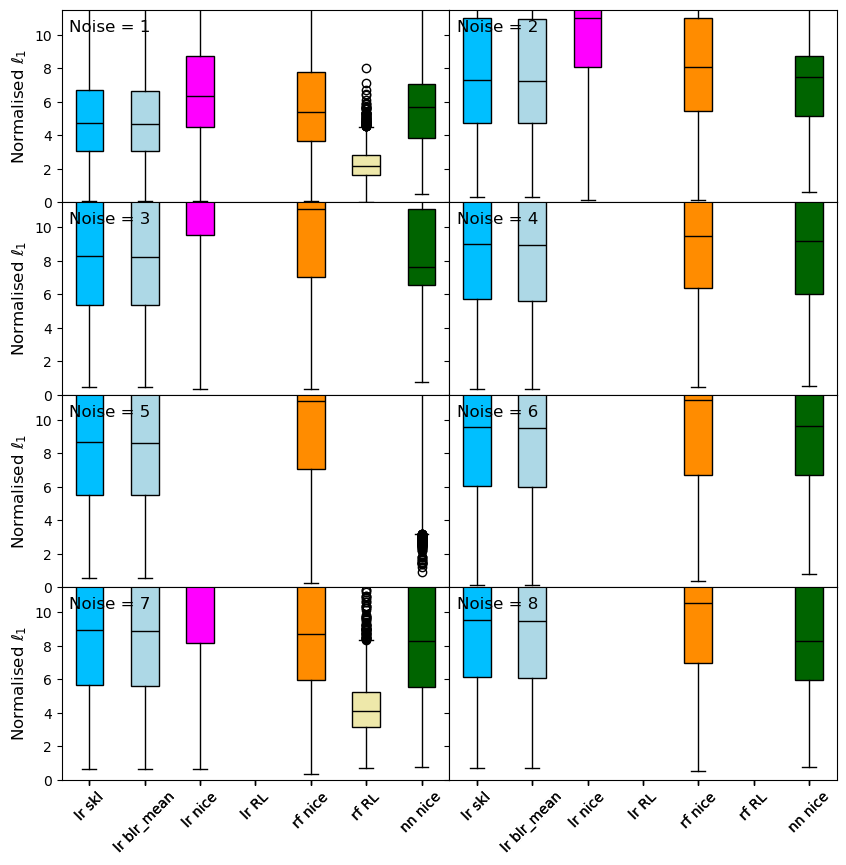

In [126]:
if dataset=="german_credit":
    n_rows, n_cols = 2, 2
else:
    n_rows, n_cols = 4, 2  # Define explicitly to be adaptable
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    d2 = []
    labels = []
    colour_list = []
    
    # Define the total number of labels expected (assuming 11 methods)
    expected_labels = [k[0] + ' ' + k[1] for k in cf_methods]  # All possible labels
    expected_d2 = {label: [] for label in expected_labels}  # Dictionary to store distances

    for k in cf_methods:
        colour_list.append(colours[k])
        A = cf_results_dict[noises_list[i]][k]
        B = cf_results_dict['noise_0'][k]

        if k[1] in {'nice', 'dice', 'RL'} and k[0] != 'tf':
            A = cf_calc[i].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        good_indices = cfs_good_indices[noises_list[i]][k]
        
        if sum(good_indices) / len(good_indices) > completeness_limit:
            expected_d2[k[0] + ' ' + k[1]] = get_distance(
                A[good_indices], B[good_indices], numerical_columns, categorical_columns, 
                l_norm=l_order,)

    # Ensure that all expected labels appear, even if they have no data points
    d2 = list(expected_d2.values())  # Boxplot data (some lists will be empty)
    labels = [s.replace("tf", "nn", 1) if s.startswith("tf") else s for s in expected_d2.keys()] #list(expected_d2.keys())  # Ensure all labels appear

    # Apply x-labels only for the last row
    if i // n_cols == n_rows - 1:
        bplot = ax.boxplot(d2, tick_labels=labels, widths=0.5, patch_artist=True)
    else:
        bplot = ax.boxplot(d2, tick_labels=['' for _ in labels], widths=0.5, patch_artist=True)

    ax.set_ylim([0, 11.5])

    for patch, color in zip(bplot['boxes'], colour_list):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')

    ax.text(0.02, 0.95, 'Noise = ' + noises_list[i][6:9], fontsize=12,
            verticalalignment='top', horizontalalignment='left',
            transform=ax.transAxes)
    
    # Set y-labels for leftmost column
    if i % n_cols == 0:
        ax.set_ylabel(r'Normalised $\ell_1$', fontsize=12)

    ax.tick_params(axis='x', labelrotation=45)

fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
fig.savefig("plots/"+dataset+"_"+variant+"_relative.pdf", format="pdf", bbox_inches="tight")


In [127]:
def model_dict_to_df(model_dict):
    df = pd.DataFrame.from_dict(model_dict, orient='index', columns=['value'])
    df.index = pd.MultiIndex.from_tuples(df.index, names=['model', 'metric'])
    df = df.unstack(level=1)
    df.columns = df.columns.droplevel(1)
    df = df.reset_index()
    df.columns = ['model','accuracy', 'precision']
    return df

In [128]:
methods2 = ['R19', 'BR19 (Mean)', 'BR19 (Marg)', 'DiCE', 'NICE', 'RL']
d2 = {'R19':[('lr', 'skl')], 
      'BR19 (Marg)':[('lr', 'blr_marg')], 
      'BR19 (Mean)':[('lr', 'blr_mean')], 
      'DiCE': [('lr', 'dice'), ('rf', 'dice'),('tf', 'dice')],
      'NICE': [('lr', 'nice'), ('rf', 'nice'),('tf', 'dice')],
      'RL': [('lr', 'RL'),('rf', 'RL')]}

Save processed outputs (maybe obsolete)

In [129]:
dfs = []
for i in model_results_dict:
    df_t = model_dict_to_df(model_results_dict[i])
    df_t.insert(0,'Noise Level',i)
    df_t.insert(0,'Variant',variant)
    df_t.insert(0,'Dataset',dataset)
    dfs.append(df_t)
df = pd.concat(dfs).reset_index(drop=True) # dfs concatanation here

for j in [i+' Compl' for i in methods2]:
    df[j] = np.nan
for j in [i+' L1' for i in methods2]:
    df[j] = np.nan
for j in [i+' L2' for i in methods2]:
    df[j] = np.nan
    
for noise in list(cf_results_dict.keys()):
    ii = int(noise.split("_")[-1])
    for k in methods2:
        for m in d2[k]:
            try:
                compl = sum(cfs_good_indices[noise][m])/len(cfs_good_indices[noise][m])
                if m[1]=='skl':
                    model_sel = 'lr'
                elif m[1]=='blr_mean':
                    model_sel = 'blr'
                elif m[1]=='blr_marg':
                    model_sel = 'blr'
                else:
                    model_sel = m[0]
                sel = (df['Noise Level']==noise)&(df['model']==model_sel)
                df.loc[sel, k+' Compl'] = compl
                A = cf_results_dict[noise][m]
                B = cf_results_dict['noise_0'][m]
                if m[1]=='nice' or m[1]=='dice' or m[1]=='RL':
                    if m[0]!='tf':
                        A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
                        B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
                good_indices = cfs_good_indices[noise][m]
                df.loc[sel,k+' L1'] = get_distance(
                    A[good_indices], B[good_indices], numerical_columns, categorical_columns, 
                    l_norm=1).mean()
                df.loc[sel,k+' L2'] = get_distance(
                    A[good_indices], B[good_indices], numerical_columns, categorical_columns, 
                    l_norm=2).mean()
            except KeyError:
                pass
#df.to_csv('data/output_'+dataset+"_"+variant+".csv", index=False)

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/var/folders/v3/8m8d5hfj2zdby10rq6l2ttyw0000gn/T/ipykernel_89949/299572322.py:42: RuntimeWarning: Mean of empty slice.
  l_norm=1).mean()
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 

In [130]:
def add_text_in_subplot(ax_in,text_in):
    xlim = ax_in.get_xlim()
    ylim = ax_in.get_ylim()
    x_text = xlim[0] + 0.02 * (xlim[1] - xlim[0])  # 2% from left
    y_text = ylim[1] - 0.05 * (ylim[1] - ylim[0])  # 5% from top
    ax_in.text(x_text, y_text, text_in, fontsize=10, verticalalignment='top', horizontalalignment='left')
    return

If adult income save table with individual movement, else if give me some credit save plot with movement

('lr', 'blr_mean')


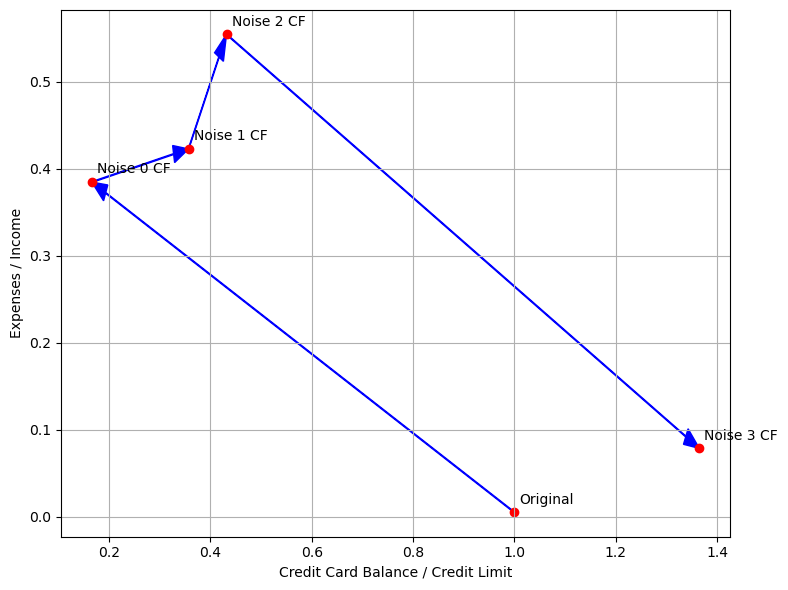

In [131]:
if dataset == "adult_income":
    num_feat = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
    cat_feat = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'native-country']
    cols = cat_feat + num_feat
    sel = cf_calc[0].cm_data['lr']=='FN'
    row_in = 70 #58 #56 #55 #2
    ml_cf = list(cf_results_dict['noise_1'].keys())[3]
    print(ml_cf)
    s0 = pd.Series(cf_calc[0].df_test[sel].iloc[row_in].values, index=cols)
    s1 = pd.Series(np.array(cf_results_dict[noises_list[0]][ml_cf])[sel][row_in], index=cols)
    s2 = pd.Series(np.array(cf_results_dict[noises_list[1]][ml_cf])[sel][row_in], index=cols)
    s3 = pd.Series(np.array(cf_results_dict[noises_list[2]][ml_cf])[sel][row_in], index=cols)
    s4 = pd.Series(np.array(cf_results_dict[noises_list[3]][ml_cf])[sel][row_in], index=cols)
    df_paper = pd.concat([s0,s1,s2,s3,s4],axis=1)
    df_paper.columns = ['Original', 'Noise 0 CF', 'Noise 1 CF', 'Noise 2 CF', 'Noise 3 CF']

    
elif dataset == "gsc":
    num_feat = [str(i) for i in range(10)]
    cols = num_feat
    row_in = 6
    sel = cf_calc[0].cm_data['lr']=='FP'
    ml_cf = list(cf_results_dict['noise_1'].keys())[1]

    print(ml_cf)
    s0 = pd.Series(cf_calc[0].df_test[sel].iloc[row_in].values, index=cols)
    s1 = pd.Series(np.array(cf_results_dict[noises_list[0]][ml_cf])[sel][row_in], index=cols)
    s2 = pd.Series(np.array(cf_results_dict[noises_list[1]][ml_cf])[sel][row_in], index=cols)
    s3 = pd.Series(np.array(cf_results_dict[noises_list[2]][ml_cf])[sel][row_in], index=cols)
    s4 = pd.Series(np.array(cf_results_dict[noises_list[3]][ml_cf])[sel][row_in], index=cols)
    df_paper = pd.concat([s0,s1,s2,s3,s4],axis=1).iloc[[0,3]]
    df_paper.index = ['credit card balance over credit limit', 'expenses over income']
    df_paper.columns = ['Original', 'Noise 0 CF', 'Noise 1 CF', 'Noise 2 CF', 'Noise 3 CF']

    # Plot with arrows
    plt.figure(figsize=(8, 6))
    for i in range(len(df_paper.T) - 1):
        x, y = df_paper.T.iloc[i]
        dx, dy = df_paper.T.iloc[i + 1] - df_paper.T.iloc[i]
        plt.arrow(x, y, dx, dy, head_width=0.02, length_includes_head=True, color='blue')

    # Plot points
    plt.scatter(df_paper.T['credit card balance over credit limit'], df_paper.T['expenses over income'], c='red')
    for label, (x, y) in df_paper.T.iterrows():
        plt.text(x + 0.01, y + 0.01, label)

    plt.xlabel("Credit Card Balance / Credit Limit")
    plt.ylabel("Expenses / Income")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("plots/"+dataset+"_"+variant+"_CF_move.pdf", format="pdf", bbox_inches="tight")
else:
    pass

# print(ml_cf)
# for row_in in range(100):
#     s0 = pd.Series(cf_calc[0].df_test[sel].iloc[row_in].values, index=cols)
#     s1 = pd.Series(np.array(cf_results_dict[noises_list[0]][ml_cf])[sel][row_in], index=cols)
#     s2 = pd.Series(np.array(cf_results_dict[noises_list[1]][ml_cf])[sel][row_in], index=cols)
#     s3 = pd.Series(np.array(cf_results_dict[noises_list[2]][ml_cf])[sel][row_in], index=cols)
#     s4 = pd.Series(np.array(cf_results_dict[noises_list[3]][ml_cf])[sel][row_in], index=cols)
#     df_paper = pd.concat([s0,s1,s2,s3,s4],axis=1).iloc[[0,3]]
#     df_paper.columns = ['Original', 'Noise 0 CF', 'Noise 1 CF', 'Noise 2 CF', 'Noise 3 CF']
#     if (df_paper>=0).all(axis=None):
#         print(row_in, df_paper)
#         break

In [132]:
if dataset == "adult_income":
    latex_str = df_paper.to_latex(index=True, header=True, escape=True, float_format="%.0f")
    print(latex_str)

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/co

('rf', 'nice')
[ 5.39275467  8.04668079 11.07176785  9.48671502 11.08773161 11.15078008
  8.71589245 10.54092896 10.20644572 10.57806827]
('tf', 'nice')
nn nice


/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


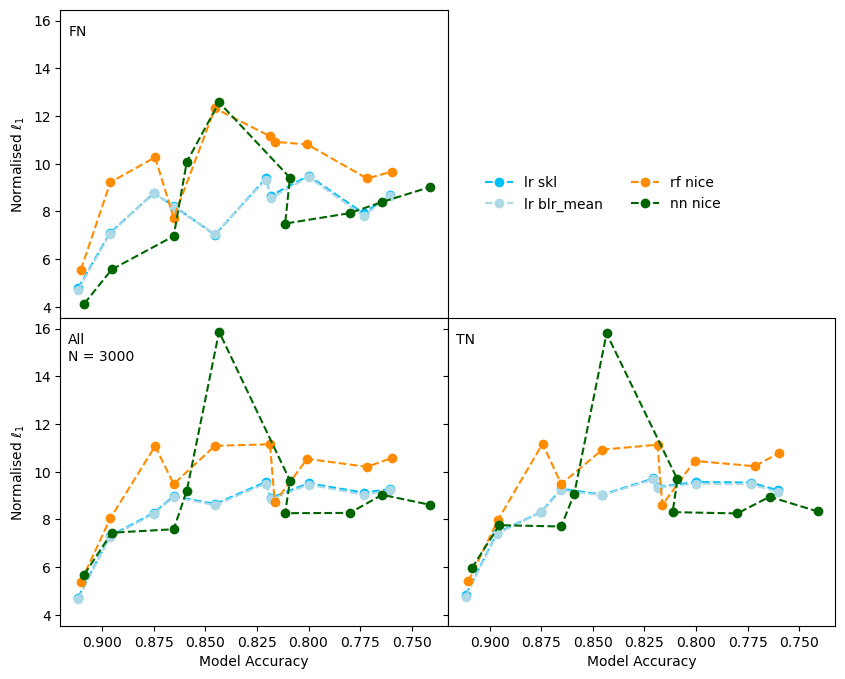

In [133]:
#fig, axes = plt.subplots(2, 2, figsize=(10, 8), gridspec_kw={'height_ratios': [1, 1], 'width_ratios': [1, 1]})
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
(ax_top, _), (ax_bottom_left, ax_bottom_right) = axes

# Remove the top-right plot
fig.delaxes(axes[0, 1])  # This removes the top-right subplot

# fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, sharey=True)
# ax_top, (ax_bottom_left, ax_bottom_right) = axes[0], axes[1].subplots(1, 2, sharex=True, sharey=True)

stats_out = {}

for i, kk in enumerate(cf_methods):
    if dataset=='adult_income' and (kk[1]=='skl' or kk[1]=='blr_mean'): continue # lr are not showing very well for adult income
    x_acc = []
    d2 = []
    compl = {}

    for k in cf_results_dict:
        if k == 'noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]

        if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
            A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        good_indices = cfs_good_indices[k][kk]

        # Default: Original Selection
        d_temp = get_distance(A[good_indices], B[good_indices], numerical_columns, categorical_columns, l_norm=l_order)
        if len(d_temp) > 0:
            d2.append(d_temp)
            compl[(kk, k)] = (sum(good_indices) / len(good_indices))
            x_acc.append(model_results_dict[k][(kk[0], 'accuracy')])

    #d2 = np.array([np.array([np.mean(i), np.percentile(i, 25), np.percentile(i, 75)]) for i in d2])
    d2 = np.array([np.array([np.percentile(i, 50), np.percentile(i, 10), np.percentile(i, 90), np.percentile(i, 75) - np.percentile(i, 25)]) for i in d2])
    stats_out[kk] = d2

    if len(d2) == 0:
        continue

    # -----------------------------
    # Top Plot (False Negatives - FN) with good_indices
    # -----------------------------
    x_acc_fn = []
    d2_fn = []
    for k in cf_results_dict:
        if k == 'noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]

        if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
            A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        fn_indices = (cf_calc[ii-1].cm_data['blr'] == 'FN') #& good_indices
        d_temp_fn = get_distance(A[fn_indices], B[fn_indices], numerical_columns, categorical_columns, l_norm=l_order)

        if len(d_temp_fn) > 0:
            d2_fn.append(d_temp_fn)
            x_acc_fn.append(model_results_dict[k][(kk[0], 'accuracy')])

    #d2_fn = np.array([np.array([np.mean(i), np.percentile(i, 25), np.percentile(i, 75)]) for i in d2_fn])
    d2_fn = np.array([np.array([np.percentile(i, 50), np.percentile(i, 10), np.percentile(i, 90), np.percentile(i, 75) - np.percentile(i, 25)]) for i in d2_fn])

    if len(d2_fn) > 0:
        if any(value < completeness_limit for value in compl.values()):
            pass
        else:
            ax_top.plot(x_acc_fn, d2_fn[:, 0], color=colours[kk], label=kk[0] + ' ' + kk[1], alpha=1, linestyle='--', marker='o')

    # -----------------------------
    # Bottom-Right Plot (True Negatives - TN) with good_indices
    # -----------------------------
    x_acc_tn = []
    d2_tn = []
    for k in cf_results_dict:
        if k == 'noise_0': continue
        ii = int(k.split("_")[-1])
        A = cf_results_dict[k][kk]
        B = cf_results_dict['noise_0'][kk]

        if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
            A = cf_calc[ii-1].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[0].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)

        tn_indices = (cf_calc[ii-1].cm_data['blr'] == 'TN') #& good_indices
        d_temp_tn = get_distance(A[tn_indices], B[tn_indices], numerical_columns, categorical_columns, l_norm=l_order)

        if len(d_temp_tn) > 0:
            d2_tn.append(d_temp_tn)
            x_acc_tn.append(model_results_dict[k][(kk[0], 'accuracy')])

    #d2_tn = np.array([np.array([np.mean(i), np.percentile(i, 25), np.percentile(i, 75)]) for i in d2_tn])
    d2_tn = np.array([np.array([np.percentile(i, 50), np.percentile(i, 10), np.percentile(i, 90), np.percentile(i, 75) - np.percentile(i, 25)]) for i in d2_tn])

    if len(d2_tn) > 0:
        if any(value < completeness_limit for value in compl.values()):
            pass
        else:
            if kk[0]=='tf':
                label_mod = 'nn ' + kk[1] # replacing labels with tf to nn
            else: 
                label_mod = kk[0] + ' ' + kk[1]
            ax_bottom_right.plot(x_acc_tn, d2_tn[:, 0], color=colours[kk], label=label_mod, alpha=1, linestyle='--', marker='o')

    # -----------------------------
    # Standard Plot (Bottom-Left)
    # -----------------------------
    if any(value < completeness_limit for value in compl.values()):
        pass
    else:
        if kk[0]=='rf':
            print(kk)
            print(d2[:,0])
        if kk[0]=='tf':
            print(kk)
            label_mod = 'nn ' + kk[1] # replacing labels with tf to nn
            print(label_mod)
        else: 
            label_mod = kk[0] + ' ' + kk[1]
        ax_bottom_left.plot(x_acc, d2[:, 0], color=colours[kk], label=label_mod, alpha=1, linestyle='--', marker='o')

# Formatting plots
for ax in [ax_top, ax_bottom_left, ax_bottom_right]:
    ax.set_xlabel('Model Accuracy')
    ax.invert_xaxis()
    #ax.set_ylim([0,2])

add_text_in_subplot(ax_bottom_left,'All\nN = ' + str(len(good_indices)))
add_text_in_subplot(ax_bottom_right,'TN')
add_text_in_subplot(ax_top,'FN')
#add_text_in_subplot(ax_bottom_right,'TN\nN = ' + str(tn_indices.sum()))
#add_text_in_subplot(ax_top,'FN\nN = ' + str(fn_indices.sum()))

ax_bottom_right.legend(loc="upper center", bbox_to_anchor=(0.4, 1.5), ncol=2, frameon=False)

ax_top.set_ylabel(r'Normalised $\ell_1$ ')
ax_bottom_left.set_ylabel(r'Normalised $\ell_1$ ')

fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
fig.savefig("plots/"+dataset+"_"+variant+"_l1_median_relative.pdf", format="pdf", bbox_inches="tight")

In [134]:
noise_indices = [1, 4, 8]
noise_labels = ["Low", "Medium", "High"]

per_instance_distances = {}
completeness_scores = {}  # optional: to keep track

for i, kk in enumerate(cf_methods):
    for k in cf_results_dict:
        if k == 'noise_0': 
            continue
        ii = int(k.split("_")[-1])  # noise index

        if ii in noise_indices:  # only low/med/high
            label = noise_labels[noise_indices.index(ii)]

            A = cf_results_dict[k][kk]
            B = cf_results_dict['noise_0'][kk]

            if kk[1] in ['nice', 'dice', 'RL'] and kk[0] != 'tf':
                A = cf_calc[ii-1].models[0]['PP'].transform(
                    pd.DataFrame(A, columns=[str(j) for j in range(n_features)])
                ).astype(float)
                B = cf_calc[0].models[0]['PP'].transform(
                    pd.DataFrame(B, columns=[str(j) for j in range(n_features)])
                ).astype(float)

            good_indices = cfs_good_indices[k][kk]
            d_temp = get_distance(
                A[good_indices],
                B[good_indices],
                numerical_columns,
                categorical_columns,
                l_norm=l_order
            )

            # compute completeness
            completeness = sum(good_indices) / len(good_indices)

            if completeness >= completeness_limit and len(d_temp) > 0:
                if kk not in per_instance_distances:
                    per_instance_distances[kk] = {}
                    completeness_scores[kk] = {}
                per_instance_distances[kk][label] = d_temp
                completeness_scores[kk][label] = completeness

/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/leo/anaconda3/envs/pymc5b/lib/python3.11/site-packages/numpy/co

In [135]:
stats_out = {}

# Define the function to compute stats
def describe(values):
    values = np.array(values)
    return np.array([
        np.median(values),
        np.percentile(values, 10),
        np.percentile(values, 90),
        np.percentile(values, 75) - np.percentile(values, 25)  # IQR
    ])

# Recompute stats_out
for method, noise_dict in per_instance_distances.items():
    rows = []
    for label in noise_labels:  # ensure consistent order: low, medium, high
        if label in noise_dict:
            stats = describe(noise_dict[label])
            rows.append(stats)
        else:
            rows.append(np.array([np.nan, np.nan, np.nan, np.nan]))  # missing if completeness < threshold
    stats_out[method] = np.vstack(rows)


In [136]:
noise_pos = {"Low": 0, "Medium": 1, "High": 2}

best_methods = {}
best_medians  = {}

for label, idx in noise_pos.items():
    min_median = np.inf
    best = None
    for (model, variant), stats in stats_out.items():  # stats shape: (3, 4)
        if stats.shape[0] <= idx or not np.isfinite(stats[idx, 0]):
            continue
        med = stats[idx, 0]
        if med < min_median:
            min_median = med
            best = (model, variant)
    best_methods[label] = best
    best_medians[label] = min_median

print(best_methods)
print(best_medians)

{'Low': ('rf', 'RL'), 'Medium': ('lr', 'blr_mean'), 'High': ('tf', 'nice')}
{'Low': 2.1547016932186183, 'Medium': 8.940924898111478, 'High': 8.275731768226997}


In [137]:
def compare_methods(method_best, method_other, noise_label, per_instance_distances, wilcoxon_test=True, draws=2000, tune=1000):
    """
    Compare two methods at a given noise level using Bayesian posterior and optional Wilcoxon test.
    
    Parameters
    ----------
    method_best : tuple
        The “best” method (model, variant).
    method_other : tuple
        The other method to compare.
    noise_label : str
        One of 'Low', 'Medium', 'High'.
    per_instance_distances : dict
        Nested dict per_instance_distances[method][noise_label] -> array of distances
    wilcoxon_test : bool
        If True, compute Wilcoxon signed-rank test.
    draws, tune : int
        MCMC sampling parameters.

    Returns
    -------
    dict
        {
            "posterior_prob_best_better": float (P(delta < 0)),
            "median_delta": float,
            "wilcoxon_p": float (or None if wilcoxon_test=False)
        }
    """
    
    # Get per-instance distances
    try:
        dist_best = per_instance_distances[method_best][noise_label]
    except KeyError:
        return {
        "posterior_prob_best_better": np.nan,
        "median_delta": np.nan,
        "wilcoxon_p": np.nan
    }

    try:
        dist_other = per_instance_distances[method_other][noise_label]
    except KeyError:
        return {
        "posterior_prob_best_better": np.nan,
        "median_delta": np.nan,
        "wilcoxon_p": np.nan
    }
    # Bayesian model
    with pm.Model() as model:
        mu_best = pm.Normal("mu_best", mu=0, sigma=5)
        mu_other = pm.Normal("mu_other", mu=0, sigma=5)
        sigma_best = pm.HalfCauchy("sigma_best", 2)
        sigma_other = pm.HalfCauchy("sigma_other", 2)

        obs_best = pm.StudentT("obs_best", nu=3, mu=mu_best, sigma=sigma_best, observed=dist_best)
        obs_other = pm.StudentT("obs_other", nu=3, mu=mu_other, sigma=sigma_other, observed=dist_other)

        delta = pm.Deterministic("delta", mu_best - mu_other)

        trace = pm.sample(draws=draws, tune=tune, target_accept=0.9, progressbar=False)

    # Posterior probability that best method is better (delta < 0)
    posterior_prob = (trace.posterior["delta"] < 0).mean().values
    median_delta = np.median(trace.posterior["delta"].values)
    
    # Wilcoxon signed-rank test (optional)
    if wilcoxon_test:
        try:
            stat, p_val = wilcoxon(dist_best, dist_other, alternative='less')  # best expected smaller
        except ValueError:
            p_val = np.nan  # if distributions are identical or too short
    else:
        p_val = None

    return {
        "posterior_prob_best_better": posterior_prob,
        "median_delta": median_delta,
        "wilcoxon_p": p_val
    }

In [138]:
# Prepare table
rows = []

for noise_label in noise_labels:  # ["Low","Medium","High"]
    print(noise_label)
    best_method = best_methods[noise_label]
    print(best_method)
    for method in per_instance_distances.keys():
        if method == best_method:
            continue  # skip best method itself
        print(method)
        res = compare_methods(best_method, method, noise_label, per_instance_distances, wilcoxon_test=True)

        rows.append({
            "Noise": noise_label,
            "Method": f"{method[0]}-{method[1]}",
            "Median Delta": res["median_delta"],
            "Posterior Prob Best Better": res["posterior_prob_best_better"],
            "Wilcoxon P": res["wilcoxon_p"],
            "Significance": p_to_stars(res["wilcoxon_p"])
        })

# Build DataFrame
df_results = pd.DataFrame(rows)

# Optional: pivot for LaTeX format
table_wide = df_results.pivot(index="Method", columns="Noise", 
                              values=["Median Delta","Posterior Prob Best Better","Significance"])

# Export to LaTeX
latex_table = table_wide.to_latex(multicolumn=True, multirow=True, float_format="%.2f", escape=False)
print(latex_table)

Low
('rf', 'RL')
('lr', 'skl')


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_best, mu_other, sigma_best, sigma_other]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


('lr', 'blr_mean')


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_best, mu_other, sigma_best, sigma_other]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


('lr', 'nice')


...

('lr', 'blr_mean')


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_best, mu_other, sigma_best, sigma_other]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


('lr', 'nice')
('rf', 'nice')


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_best, mu_other, sigma_best, sigma_other]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


('rf', 'RL')
\begin{tabular}{llllllllll}
\toprule
 & \multicolumn{3}{r}{Median Delta} & \multicolumn{3}{r}{Posterior Prob Best Better} & \multicolumn{3}{r}{Significance} \\
Noise & High & Low & Medium & High & Low & Medium & High & Low & Medium \\
Method &  &  &  &  &  &  &  &  &  \\
\midrule
lr-blr_mean & -0.89 & -2.53 & NaN & 1.0 & 1.0 & NaN & *** &  & NaN \\
lr-nice & NaN & -4.24 & NaN & NaN & 1.0 & NaN &  &  &  \\
lr-skl & -0.95 & -2.59 & -0.06 & 1.0 & 1.0 & 0.65575 & *** &  & *** \\
rf-RL & NaN & NaN & NaN & NaN & NaN & NaN &  & NaN &  \\
rf-nice & -1.96 & -3.29 & -0.55 & 1.0 & 1.0 & 1.0 & *** &  & *** \\
tf-nice & NaN & -3.41 & -0.17 & NaN & 1.0 & 0.892625 & NaN &  & * \\
\bottomrule
\end{tabular}



In [139]:
# Build DataFrame
df_results = pd.DataFrame(rows)

# Optional: pivot for LaTeX format
table_wide = df_results.pivot(index="Method", columns="Noise", 
                              values=["Median Delta","Posterior Prob Best Better","Significance"])

# Export to LaTeX
latex_table = table_wide.to_latex(multicolumn=True, multirow=True, float_format="%.2f", escape=False)
print(latex_table)

\begin{tabular}{llllllllll}
\toprule
 & \multicolumn{3}{r}{Median Delta} & \multicolumn{3}{r}{Posterior Prob Best Better} & \multicolumn{3}{r}{Significance} \\
Noise & High & Low & Medium & High & Low & Medium & High & Low & Medium \\
Method &  &  &  &  &  &  &  &  &  \\
\midrule
lr-blr_mean & -0.89 & -2.53 & NaN & 1.0 & 1.0 & NaN & *** &  & NaN \\
lr-nice & NaN & -4.24 & NaN & NaN & 1.0 & NaN &  &  &  \\
lr-skl & -0.95 & -2.59 & -0.06 & 1.0 & 1.0 & 0.65575 & *** &  & *** \\
rf-RL & NaN & NaN & NaN & NaN & NaN & NaN &  & NaN &  \\
rf-nice & -1.96 & -3.29 & -0.55 & 1.0 & 1.0 & 1.0 & *** &  & *** \\
tf-nice & NaN & -3.41 & -0.17 & NaN & 1.0 & 0.892625 & NaN &  & * \\
\bottomrule
\end{tabular}



In [140]:
# Map noise labels to positions in stats_out (0 = Low, 1 = Medium, 2 = High)
noise_pos = {"Low": 0, "Medium": 1, "High": 2}

rows = []
for (model, variant), stats in stats_out.items():
    for label, idx in noise_pos.items():
        median, p10, p90, iqr = stats[idx]
        rows.append({
            "ML-CF Method": f"{model}-{variant}",
            "Uncertainty": label,
            "Median": median,
            "P10": p10,
            "P90": p90,
            "IQR": iqr
        })

df = pd.DataFrame(rows)

# Pivot into wide format
table = df.pivot(index="ML-CF Method", columns="Uncertainty", values=["Median","P10","P90","IQR"])

# Function to bold the minimum value in each column
def bold_min(s):
    is_min = s == s.min()
    return [f"\\textbf{{{v:.2f}}}" if m else f"{v:.2f}" for v, m in zip(s, is_min)]

# Apply per column (for each stat across methods at fixed uncertainty)
formatted = table.copy()
for stat in table.columns.levels[0]:
    formatted[stat] = table[stat].apply(bold_min, axis=0)

# Export LaTeX
latex_table = formatted.to_latex(multicolumn=True, multirow=True, escape=False)
print(latex_table)

\begin{tabular}{lllllllllllll}
\toprule
 & \multicolumn{3}{r}{Median} & \multicolumn{3}{r}{P10} & \multicolumn{3}{r}{P90} & \multicolumn{3}{r}{IQR} \\
Uncertainty & High & Low & Medium & High & Low & Medium & High & Low & Medium & High & Low & Medium \\
ML-CF Method &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
lr-blr_mean & 9.46 & 4.65 & \textbf{8.94} & \textbf{3.85} & 1.99 & 3.64 & 18.71 & 8.73 & 17.23 & 7.95 & 3.56 & 7.55 \\
lr-nice & nan & 6.33 & nan & nan & 3.01 & nan & nan & 11.09 & nan & nan & 4.27 & nan \\
lr-skl & 9.52 & 4.72 & 8.98 & 3.87 & 2.02 & 3.68 & 18.72 & 8.82 & 17.27 & 8.01 & 3.61 & 7.50 \\
rf-RL & nan & \textbf{2.15} & nan & nan & \textbf{1.27} & nan & nan & \textbf{3.48} & nan & nan & \textbf{1.15} & nan \\
rf-nice & 10.54 & 5.39 & 9.49 & 4.37 & 2.30 & 4.58 & 19.66 & 10.13 & \textbf{16.95} & 8.02 & 4.15 & 6.81 \\
tf-nice & \textbf{8.28} & 5.69 & 9.20 & 4.12 & 2.36 & \textbf{2.97} & \textbf{17.81} & 8.28 & 17.74 & \textbf{6.93} & 3.27 & \textbf{6.63} \\
\bottomrule

lr [0.931, 0.9116666666666666, 0.8963333333333333, 0.875, 0.8653333333333333, 0.8453333333333334, 0.8206666666666667, 0.8183333333333334, 0.8, 0.7733333333333333, 0.7603333333333333]
blr [0.931, 0.9116666666666666, 0.8963333333333333, 0.875, 0.8653333333333333, 0.8453333333333334, 0.8206666666666667, 0.8183333333333334, 0.8, 0.7733333333333333, 0.7603333333333333]
rf [0.935, 0.9103333333333333, 0.896, 0.8743333333333333, 0.8653333333333333, 0.8453333333333334, 0.8186666666666667, 0.8163333333333334, 0.8006666666666666, 0.7716666666666666, 0.7596666666666667]
tf [0.9343333333333333, 0.9086666666666666, 0.8953333333333333, 0.8653333333333333, 0.859, 0.8433333333333334, 0.809, 0.8113333333333334, 0.78, 0.7643333333333333, 0.741]


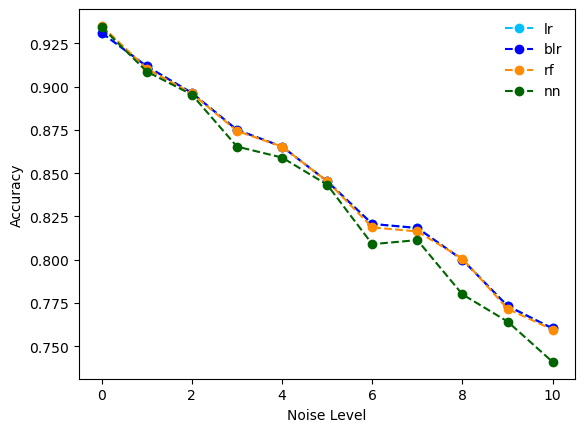

In [141]:
colours2 = {'lr': 'deepskyblue', 'blr': 'blue', 'rf':'darkorange', 'tf':'darkgreen'}
mm = []
for i, kk in enumerate(cf_methods):
    x_acc = []
    x_prec = []
    if kk[1]=='blr_mean':
        m_in = 'blr'
    else:
        m_in = kk[0]
    if m_in in mm: continue
    mm.append(m_in)
    for k in cf_results_dict:
        x_acc.append(model_results_dict[k][(kk[0], 'accuracy')])
        x_prec.append(model_results_dict[k][(kk[0], 'precision')])
    print(m_in, x_acc)
    if m_in=='tf':
        label_in = 'nn'
    else:
        label_in=m_in
    plt.plot(x_acc, label=label_in, color=colours2[m_in], linestyle='--', marker='o')
    #plt.plot(x_prec, label=m_in, color=colours2[m_in], linestyle='-.', marker='s')
plt.legend(frameon=False)
plt.xlabel('Noise Level')
plt.ylabel('Accuracy')
plt.savefig("plots/"+dataset+"_"+variant+"_accuracy.pdf", format="pdf", bbox_inches="tight")

In [142]:
one

NameError: name 'one' is not defined

In [ ]:
# colours2 = {'lr': 'deepskyblue', 'blr': 'blue', 'rf': 'darkorange', 'tf': 'darkgreen'}
# mm = []

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # Create two subplots
# ax1, ax2 = axes  # Unpack the subplots

# for i, kk in enumerate(cf_methods):
#     x_acc = []
#     x_prec = []
#     if kk[1] == 'blr_mean':
#         m_in = 'blr'
#     else:
#         m_in = kk[0]
#     if m_in in mm:
#         continue
#     mm.append(m_in)
#     for k in cf_results_dict:
#         x_acc.append(model_results_dict[k][(kk[0], 'accuracy')])
#         x_prec.append(model_results_dict[k][(kk[0], 'precision')])

#     ax1.plot(x_acc, label=m_in, color=colours2[m_in], linestyle='--', marker='o')
#     ax2.plot(x_prec, label=m_in, color=colours2[m_in], linestyle='-.', marker='s')

# ax1.set_xlabel('Noise Level')
# ax1.set_ylabel('Accuracy')
# ax1.legend(frameon=False)
# #ax1.set_title('Accuracy vs Noise Level')

# ax2.set_xlabel('Noise Level')
# ax2.set_ylabel('Precision')
# ax2.legend(frameon=False)
# #ax2.set_title('Precision vs Noise Level')

# plt.tight_layout()
# #plt.savefig(f"plots/{dataset}_{variant}_accuracy_precision.pdf", format="pdf", bbox_inches="tight")
# plt.show()

In [ ]:
def find_closest_noise(data, model, target=0.75):
    closest_noise = None
    min_diff = float("inf")  # Start with a very large difference

    for noise, metrics in data.items():
        if (model, "accuracy") in metrics:
            acc = metrics[(model, "accuracy")]
            diff = abs(acc - target)  # Compute absolute difference from 0.8
            
            if diff < min_diff:  # Update if this is the closest value so far
                min_diff = diff
                closest_noise = noise

    return closest_noise

# Example usage:
# closest_noise_for_lr = find_closest_noise(model_results_dict, 'rf')
# print("Closest noise level for 'lr':", closest_noise_for_lr)

Model: ('lr', 'skl')
/Users/leo/xai-cfs/data/mock_data1
0.38582461419214786 0.4658123145007685 0.7575757575757576
/Users/leo/xai-cfs/data/mock_data2
0.9604734982099339 1.0016599515527655 0.7414141414141414
/Users/leo/xai-cfs/data/mock_data3
0.9430832926859372 0.7793909152582833 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data4
0.931483699749331 1.1186356251720742 0.7357575757575757
Model: ('lr', 'blr_mean')
/Users/leo/xai-cfs/data/mock_data1
0.37197251269599535 0.45008408161907304 0.7575757575757576
/Users/leo/xai-cfs/data/mock_data2
0.9604734982099339 1.0025977823694945 0.7414141414141414
/Users/leo/xai-cfs/data/mock_data3
0.9419523250282218 0.7881277139109223 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data4
0.931483699749331 1.1185943583094866 0.7357575757575757
Model: ('lr', 'nice')
/Users/leo/xai-cfs/data/mock_data1
0.36525381964851195 0.4402543154021178 0.7575757575757576
/Users/leo/xai-cfs/data/mock_data2
0.7782758997300049 0.8993500135531 0.7414141414141414
/Users/leo/x

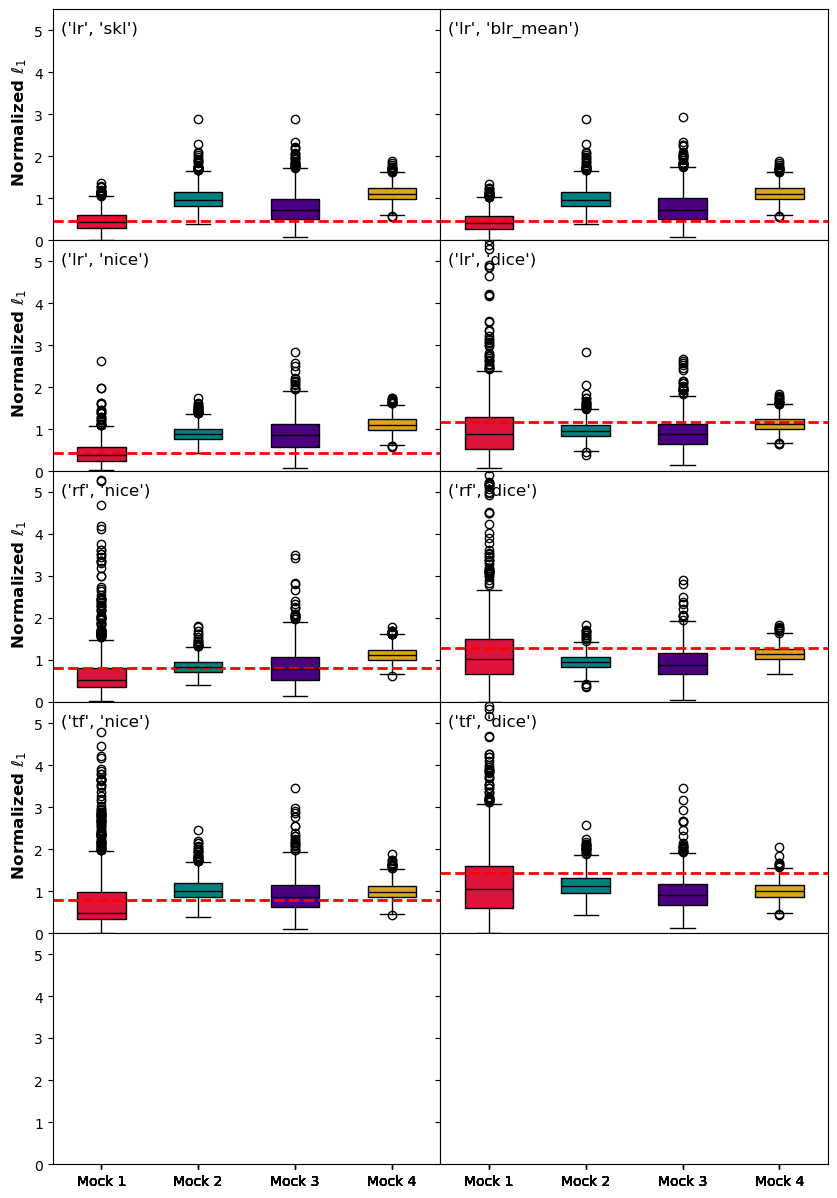

In [ ]:
l = [
    ('lr', 'skl'),
    ('lr', 'blr_mean'),
    ('lr', 'nice'),
    ('lr', 'dice'),
    ('rf', 'nice'),
    ('rf', 'dice'),
    ('tf', 'nice'),
    ('tf', 'dice')]
fig, axes = plt.subplots(5, 2, figsize=(10, 15), sharex=True, sharey=True)
for idx, ml_cf in enumerate(l):
    row, col = divmod(idx, 2)  # Convert index to 5x2 grid positions
    ax = axes[row, col]
    print("Model:",ml_cf)
    ml_1 = []
    ml_2 = []
    for i in range(1,5):
        #for v in ["standard", "ommited_var_test", "noniid_test"]:
        #    if i!=3 and v in ["ommited_var_test", "noniid_test"]: continue
        v = "standard"
        data = load_dataset("mock_data"+str(i), variant=v,n_datasets=10)
        cf_results_dict = data["cf_results_dict"]
        cf_calc = data["cf_calc"]
        model_results_dict = data["model_results_dict"]
        cfs_good_indices = data["cfs_good_indices"]
        n_features = np.array(cf_results_dict['noise_0'][('lr','nice')]).shape[1]
        numerical_columns = [int(i) for i in cf_calc[0].num_cols_tf]
        categorical_columns = [int(i) for i in cf_calc[0].cat_cols_tf]

        noise_to_test = find_closest_noise(model_results_dict, ml_cf[0])

        A = cf_results_dict['noise_0'][ml_cf]
        B = cf_results_dict[noise_to_test][ml_cf]
        if ml_cf[1] in {'nice', 'dice', 'RL'} and ml_cf[0] != 'tf':
            A = cf_calc[4].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[4].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        good_indices = cfs_good_indices[noise_to_test][ml_cf]
        m1 = get_distance(A[good_indices][:,-2:],B[good_indices][:,-2:], [0,1], [])
        m2 = get_distance(A[good_indices],B[good_indices],numerical_columns, categorical_columns, l_norm=l_order, n_features=n_features)
        ml_1.append(m1)
        ml_2.append(m2)
        print(np.mean(m1), np.mean(m2),model_results_dict[noise_to_test][(ml_cf[0], 'accuracy')])
    bplot = ax.boxplot(list(ml_2), tick_labels=['Mock 1', 'Mock 2', 'Mock 3', 'Mock 4'], widths=0.5, patch_artist=True)  # Plot boxplot for ml_1
    ax.set_ylim([0,5.5])
    if idx % n_cols == 0:
        #ax.set_ylabel(r'$\ell_1$', fontsize=12, fontweight='bold')
        ax.set_ylabel(r' Normalized $\ell_1$', fontsize=12, fontweight='bold')
    ax.text(0.02, 0.95, ml_cf, fontsize=12, verticalalignment='top', horizontalalignment='left', transform=ax.transAxes)
    ax.axhline(y=np.mean(ml_2[0]), color='red', linestyle='--', linewidth=2, label="Mean of Mock 1")
    for patch, color in zip(bplot['boxes'], ["crimson", "teal", "indigo", "goldenrod"]):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')
    print("=====================================================")
fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
#fig.savefig("plots/"+dataset+"_"+variant+"_.pdf", format="pdf", bbox_inches="tight")
#fig.supylabel(r' 2D $\ell_1$', fontsize=14)
#plt.tight_layout()

In [ ]:
l_minus_RL = [
    ('lr', 'skl'),
    ('lr', 'blr_mean'),
    ('lr', 'nice'),
    ('lr', 'dice'),
    ('rf', 'nice'),
    ('rf', 'dice'),
    ('tf', 'nice'),
    ('tf', 'dice')]

Model: ('lr', 'skl')
/Users/leo/xai-cfs/data/mock_data3
0.9430832926859372 0.7793909152582833 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data3
1.0333164865461912 0.8038123743637775 0.7373737373737373
/Users/leo/xai-cfs/data/mock_data3
2.393487763882043 1.0910488070704476 0.7484848484848485
Model: ('lr', 'blr_mean')
/Users/leo/xai-cfs/data/mock_data3
0.9419523250282218 0.7881277139109223 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data3
1.037365796498112 0.8054447459277264 0.7373737373737373
/Users/leo/xai-cfs/data/mock_data3
2.422335692792789 1.0852632936458089 0.7484848484848485
Model: ('lr', 'nice')
/Users/leo/xai-cfs/data/mock_data3
0.9899199511199246 0.8865470844968059 0.7626262626262627
/Users/leo/xai-cfs/data/mock_data3
0.9006347694782503 0.8730248644375029 0.7373737373737373
/Users/leo/xai-cfs/data/mock_data3
1.2961289137741159 1.014021902475117 0.7484848484848485
Model: ('lr', 'dice')
/Users/leo/xai-cfs/data/mock_data3
1.1365039911669976 0.9288512473425238 0.7626262626

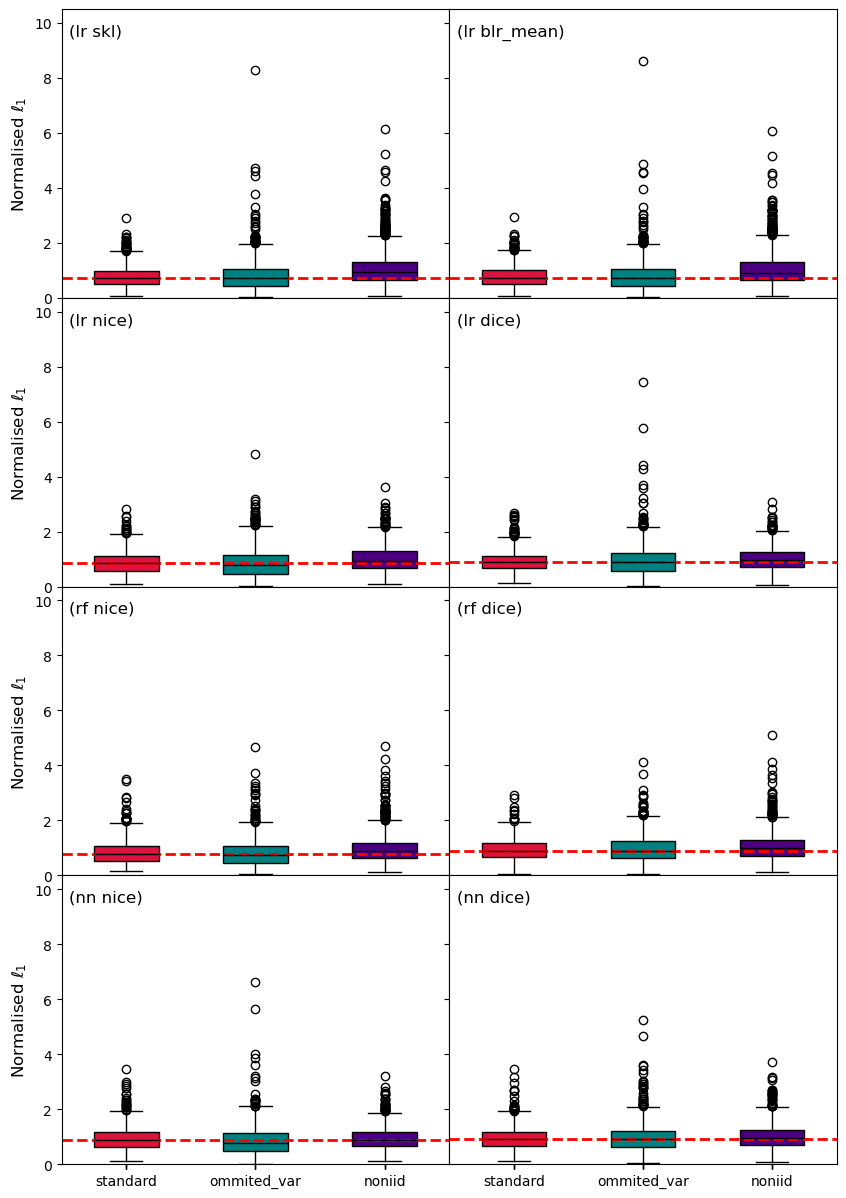

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(10, 15), sharex=True, sharey=True)
for idx, ml_cf in enumerate(l_minus_RL):
    #if ml_cf[1]=='RL': continue
    row, col = divmod(idx, 2)  # Convert index to 5x2 grid positions
    ax = axes[row, col]
    print("Model:",ml_cf)
    ml_1 = []
    ml_2 = []
    #for i in range(1,5):
    i = 3
    for v in ["standard", "ommited_var_test", "noniid_test"]:
        #if i!=3 and v in ["ommited_var_test", "noniid_test"]: continue
        #v = "standard"
        data = load_dataset("mock_data"+str(i), variant=v,n_datasets=10)
        cf_results_dict = data["cf_results_dict"]
        cf_calc = data["cf_calc"]
        model_results_dict = data["model_results_dict"]
        cfs_good_indices = data["cfs_good_indices"]
        n_features = np.array(cf_results_dict['noise_0'][('lr','nice')]).shape[1]
        numerical_columns = [int(i) for i in cf_calc[0].num_cols_tf]
        categorical_columns = [int(i) for i in cf_calc[0].cat_cols_tf]

        noise_to_test = find_closest_noise(model_results_dict, ml_cf[0])

        A = cf_results_dict['noise_0'][ml_cf]
        B = cf_results_dict[noise_to_test][ml_cf]
        if ml_cf[1] in {'nice', 'dice', 'RL'} and ml_cf[0] != 'tf':
            A = cf_calc[4].models[0]['PP'].transform(pd.DataFrame(A, columns=[str(j) for j in range(n_features)])).astype(float)
            B = cf_calc[4].models[0]['PP'].transform(pd.DataFrame(B, columns=[str(j) for j in range(n_features)])).astype(float)
        good_indices = cfs_good_indices[noise_to_test][ml_cf]
        m1 = get_distance(A[good_indices][:,-2:],B[good_indices][:,-2:], [0,1], [])
        m2 = get_distance(A[good_indices],B[good_indices],numerical_columns, categorical_columns, l_norm=l_order, ) #n_features=n_features
        ml_1.append(m1)
        ml_2.append(m2)
        print(np.mean(m1), np.mean(m2),model_results_dict[noise_to_test][(ml_cf[0], 'accuracy')])
    if idx==6 | idx==7:
        bplot = ax.boxplot(list(ml_2), tick_labels=["standard", "ommited_var", "noniid"], widths=0.5, patch_artist=True)  # Plot boxplot for ml_1
    else:
        bplot = ax.boxplot(list(ml_2), tick_labels=["","",""], widths=0.5, patch_artist=True)  # Plot boxplot for ml_1
    ax.set_ylim([0,10.5])
    if idx % n_cols == 0:
        #ax.set_ylabel(r'$\ell_1$', fontsize=12, fontweight='bold')
        ax.set_ylabel(r'Normalised $\ell_1$', fontsize=12)
    
    if ml_cf[0]=='tf':
        label_mod = '(' + 'nn' + ' ' + ml_cf[1]+ ')'
    else:
        label_mod = '(' + ml_cf[0] + ' ' + ml_cf[1]+ ')'
    ax.text(0.02, 0.95, label_mod, fontsize=12, verticalalignment='top', horizontalalignment='left', transform=ax.transAxes)
    ax.axhline(y=np.median(ml_2[0]), color='red', linestyle='--', linewidth=2, label="Mean of Mock 1")
    for patch, color in zip(bplot['boxes'], ["crimson", "teal", "indigo"]):
        patch.set_facecolor(color)
    for median in bplot['medians']:
        median.set_color('black')
    print("=====================================================")
fig.subplots_adjust(wspace=0, hspace=0)  # Set space between subplots to zero
fig.savefig("plots/epistemic_error1_relative.pdf", format="pdf", bbox_inches="tight")
#fig.supylabel(r' 2D $\ell_1$', fontsize=14)
#plt.tight_layout()

In [ ]:
# alphas = [0.5, 0.2]  # Transparency per noise level
# colors = ['darkorange', 'darkgreen']  # One for each model
# h_models = [('rf', 'nice'), ('tf', 'nice')]

# # Prepare figure with 3 panels: 1 top (KDE), 2 bottom (histograms)
# fig, axs = plt.subplots(
#     2, 2, figsize=(12, 8),
#     gridspec_kw={'height_ratios': [1, 1]},
#     sharex='col'
# )
# ax_kde = axs[0, 0]
# ax_hist_0 = axs[1, 0]
# ax_hist_1 = axs[1, 1]

# # Hide top-right panel (not used)
# axs[0, 1].axis('off')

# # Loop through models and noise levels
# for model_idx, k in enumerate(h_models):
#     for ii, i in enumerate([0, 1]):  # noise levels 0 and 1
#         A = cf_results_dict[noises_list[i]][k]
#         B = cf_results_dict['noise_0'][k]

#         if k[1] in {'nice', 'dice', 'RL'} and k[0] != 'tf':
#             A = cf_calc[i].models[0]['PP'].transform(
#                 pd.DataFrame(A, columns=[str(j) for j in range(n_features)])
#             ).astype(float)
#             B = cf_calc[0].models[0]['PP'].transform(
#                 pd.DataFrame(B, columns=[str(j) for j in range(n_features)])
#             ).astype(float)

#         good_indices = cfs_good_indices[noises_list[i]][k]

#         if sum(good_indices) / len(good_indices) > completeness_limit:
#             expected_d2[k[0] + ' ' + k[1] + f'_noise_{i}'] = get_distance(
#                 A[good_indices], B[good_indices],
#                 numerical_columns, categorical_columns, l_norm=l_order
#             )

#         l_d1 = get_distance(
#             A[good_indices], B[good_indices],
#             numerical_columns, categorical_columns, l_norm=l_order
#         )

#         acc = model_results_dict['noise_' + str(i)][(k[0], 'accuracy')]
#         acc = f'{acc:.2f}'

#         # KDE plot in top panel
#         sns.kdeplot(
#             l_d1,
#             fill=True,
#             alpha=alphas[ii],
#             color=colors[model_idx],
#             label=f"{k[0]} {k[1]}, Acc: {acc}",
#             ax=ax_kde
#         )

#         # Histogram in bottom row
#         ax_hist = ax_hist_0 if i == 0 else ax_hist_1
#         nbins=120 if i==0 else 20
#         ax_hist.hist(
#             l_d1, bins=nbins,
#             alpha=0.5,
#             facecolor=colors[model_idx],
#             edgecolor=colors[model_idx],
#             linewidth=1.5,
#             label=f"{k[0]} {k[1]}, Acc: {acc}",
#             #label=f"{k[0]} {k[1]}" if i == 0 else None  # Avoid label repetition
#         )

# # Label and legend
# ax_kde.set_xlim([0, 2])
# ax_kde.set_ylabel('Smoothed Normalized Distribution')
# ax_kde.set_xlabel('$\ell^{(CF,i)}_1 - \ell^{(CF, 0)}_1$')
# ax_kde.legend(frameon=False)

# ax_hist_0.set_ylabel('Counts')
# ax_hist_0.set_xlabel('$\ell^{(CF,i)}_1 - \ell^{(CF, 0)}_1$')
# #ax_hist_0.set_title('Histogram: Noise 0')
# ax_hist_0.legend(frameon=False)

# ax_hist_1.set_ylabel('Counts')
# ax_hist_1.set_xlabel('$\ell^{(CF,i)}_1 - \ell^{(CF, 0)}_1$')
# #ax_hist_1.set_title('Histogram: Noise 1')
# ax_hist_1.legend(frameon=False)

# plt.tight_layout()
# #plt.savefig("plots/highlight.pdf", format="pdf", bbox_inches="tight")
# plt.show()